In [1]:
import matplotlib.pyplot as plt
%matplotlib inline
import matplotlib_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('svg')
import seaborn as sns

In [2]:
# BOOK_FIGURE_STYLE_CELL
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np

try:
    import seaborn as sns
except ImportError:
    sns = None

try:
    import matplotlib_inline

    matplotlib_inline.backend_inline.set_matplotlib_formats("svg")
except Exception:
    matplotlib_inline = None

FIGURE_SIZES = {
    "full_landscape": (7.35, 4.40),
    "full_standard": (7.35, 4.90),
    "full_tall": (7.35, 5.50),
    "half_standard": (3.55, 2.55),
    "half_tall": (3.55, 3.05),
    "inset": (2.30, 1.75),
}

BOOK_COLORS = {
    "blue": "#4C78A8",
    "orange": "#F58518",
    "green": "#54A24B",
    "red": "#E45756",
    "gray": "#7F7F7F",
}

BOOK_TARGET = "web"


def setup_book_style(target="web"):
    global BOOK_TARGET
    BOOK_TARGET = target
    mpl.rcParams.update(
        {
            "figure.figsize": FIGURE_SIZES["half_standard"],
            "figure.dpi": 120,
            "savefig.dpi": 300,
            "savefig.bbox": "tight",
            "savefig.pad_inches": 0.02,
            "font.family": "sans-serif",
            "font.sans-serif": ["DejaVu Sans", "Arial", "Liberation Sans"],
            "axes.labelsize": 9,
            "axes.titlesize": 9,
            "axes.linewidth": 0.8,
            "axes.grid": False,
            "axes.spines.top": False,
            "axes.spines.right": False,
            "xtick.labelsize": 8,
            "ytick.labelsize": 8,
            "xtick.major.width": 0.8,
            "ytick.major.width": 0.8,
            "legend.fontsize": 8,
            "legend.frameon": False,
            "lines.linewidth": 1.5,
            "lines.markersize": 4,
            "patch.linewidth": 0.8,
            "image.cmap": "viridis",
        }
    )
    if target == "latex":
        try:
            mpl.rcParams["text.usetex"] = False
        except Exception:
            mpl.rcParams["text.usetex"] = False


def new_figure(
    size="half_standard",
    nrows=1,
    ncols=1,
    sharex=False,
    sharey=False,
    constrained=True,
    squeeze=True,
    **kwargs,
):
    fig, ax = plt.subplots(
        nrows=nrows,
        ncols=ncols,
        sharex=sharex,
        sharey=sharey,
        constrained_layout=constrained,
        figsize=FIGURE_SIZES[size],
        squeeze=squeeze,
        **kwargs,
    )
    return fig, ax


def label_panels(axes=None, labels=None, x=0.02, y=0.98, **kwargs):
    if axes is None:
        axes = plt.gcf().axes
    axes = np.atleast_1d(axes).ravel()
    if labels is None:
        labels = [f"({chr(97 + i)})" for i in range(len(axes))]
    default = dict(
        fontsize=9,
        fontweight="semibold",
        va="top",
        ha="left",
        transform=None,
    )
    default.update(kwargs)
    for ax, label in zip(axes, labels):
        call_kwargs = dict(default)
        if call_kwargs["transform"] is None:
            call_kwargs["transform"] = ax.transAxes
        ax.text(x, y, label, **call_kwargs)


def finalize_axes(axes=None, keep_box=False, grid=False):
    if axes is None:
        axes = plt.gcf().axes
    axes = np.atleast_1d(axes).ravel()
    for ax in axes:
        if grid:
            ax.grid(axis="y", color="0.88", linewidth=0.6)
        else:
            ax.grid(False)
        for spine in ax.spines.values():
            spine.set_linewidth(0.8)
        if keep_box:
            ax.spines["top"].set_visible(True)
            ax.spines["right"].set_visible(True)
        else:
            ax.spines["top"].set_visible(False)
            ax.spines["right"].set_visible(False)
    return axes


def save_book_figure(fig, basename, target="web", pdf=True, png=False):
    base = Path(basename)
    base.parent.mkdir(parents=True, exist_ok=True)
    if pdf:
        fig.savefig(base.with_suffix(".pdf"), bbox_inches="tight", pad_inches=0.02)
    if png:
        fig.savefig(base.with_suffix(".png"), bbox_inches="tight", pad_inches=0.02)


setup_book_style(target="web")


# Sparsity-Promoting Regularization


$L^1$-regularization is a method to prevent overfitting in linear models. It is also known as Lasso regression. It adds a penalty term to the loss function, which is the sum of the absolute values of the coefficients. This forces the coefficients to be small, and some of them to be exactly zero. This is useful for feature selection, as it allows us to discard some of the features.

Suppose we have $N$ input--response pairs $(x_i,y_i)$ and $M$ candidate features collected in $\boldsymbol{\phi}(x)$. We fit the linear basis-function model:

$$
y = w_0 + \mathbf{w}^T\boldsymbol{\phi}(x) + \epsilon.
$$

Here $\mathbf{w}$ contains the feature coefficients, $w_0$ is the bias or intercept, and $\epsilon$ is observation noise. 

We can add the $L^1$-regularization term to the usual sum of square errors loss function:

$$
L = \frac{1}{N}\sum_{i=1}^N(y_i - w_0 - \mathbf{w}^T\boldsymbol{\phi}(x_i))^2 + \lambda\|\mathbf{w}\|_1,
$$

where $\lambda\geq0$ controls the penalty strength.
The $L^1$-norm of the vector $\mathbf{w}$ is defined as:

$$
\|\mathbf{w}\|_1 = \sum_{j=1}^M|w_j|.
$$

Notice that the bias term $w_0$ is not regularized.
We don't want to push it to zero, as it is a constant term, and it is not related to the features.

Let's illustrate $L^1$-regularization with a simple example. We generate noisy data from a cubic polynomial and fit a larger library of polynomial and Fourier features. The penalty helps us select a smaller subset of terms.

Here are the data:



array([<Axes: xlabel='x', ylabel='y'>], dtype=object)

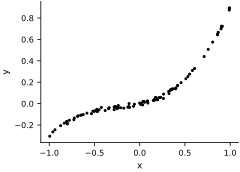

In [3]:
import numpy as np

rng = np.random.default_rng(697)
num_samples = 100
f = lambda x: 0.2 * x + 0.3 * x**2 + 0.4 * x**3
sigma = 0.01
x = rng.uniform(-1, 1, num_samples)
y = f(x) + rng.normal(0, sigma, num_samples)

fig, ax = plt.subplots(figsize=FIGURE_SIZES["half_standard"])
ax.plot(x, y, '.', color='k')
ax.set(xlabel='x', ylabel='y')
finalize_axes(keep_box=False)

We will try to fit a ridiculously complicated model.
We will have a degree-ten polynomial, and then we will also add a bunch of Fourier terms:

In [4]:
from jax import config
config.update("jax_enable_x64", True)
import jax.numpy as jnp
from jax import vmap

@vmap
def features(x):
    tmp1 = jnp.array([x ** i for i in range(1, 11)])
    tmp2 = jnp.array([jnp.sin(2 * np.pi * x * i) for i in range(1, 11)])
    return jnp.concatenate([tmp1, tmp2])

Visualize the features:

array([<Axes: xlabel='x', ylabel='feature value'>], dtype=object)

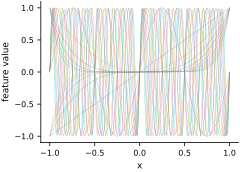

In [5]:
xs = jnp.linspace(-1, 1, 200)
Phi = features(xs)
fig, ax = plt.subplots(figsize=FIGURE_SIZES["half_standard"])
ax.plot(xs, Phi, lw=0.2)
ax.set(xlabel='x', ylabel='feature value')
finalize_axes(keep_box=False)

Clearly an overkill. But Lasso regression will still be able to throw away the unnecessary terms.

In what follows we do Lasso regression using the `sklearn` library.
We use ``LassoCV``, which also does cross-validation to find the best value of the regularization parameter $\lambda$.

In [6]:
from sklearn import linear_model

Phi_train = features(x)
clf = linear_model.LassoCV(fit_intercept=True, max_iter=100000, tol=1e-8) 
clf.fit(Phi_train, y)
lr = linear_model.RidgeCV(fit_intercept=True)
lr.fit(Phi_train, y)

,"alphas alphas: array-like of shape (n_alphas,), default=(0.1, 1.0, 10.0)Array of alpha values to try.Regularization strength; must be a positive float. Regularizationimproves the conditioning of the problem and reduces the variance ofthe estimates. Larger values specify stronger regularization.Alpha corresponds to ``1 / (2C)`` in other linear models such as:class:`~sklearn.linear_model.LogisticRegression` or:class:`~sklearn.svm.LinearSVC`.If using Leave-One-Out cross-validation, alphas must be strictly positive.For an example on how regularization strength affects the model coefficients,see :ref:`sphx_glr_auto_examples_linear_model_plot_ridge_coeffs.py`.","(0.1, ...)"
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto false, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"scoring scoring: str, callable, default=NoneThe scoring method to use for cross-validation. Options:- str: see :ref:`scoring_string_names` for options.- callable: a scorer callable object (e.g., function) with signature ``scorer(estimator, X, y)``. See :ref:`scoring_callable` for details.- `None`: negative :ref:`mean squared error <mean_squared_error>` if cv is None (i.e. when using leave-one-out cross-validation), or :ref:`coefficient of determination <r2_score>` (:math:`R^2`) otherwise.",None
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the efficient Leave-One-Out cross-validation- integer, to specify the number of folds,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if ``y`` is binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used, else,:class:`~sklearn.model_selection.KFold` is used.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here.",None
,"gcv_mode gcv_mode: {'auto', 'svd', 'eigen'}, default='auto'Flag indicating which strategy to use when performingLeave-One-Out Cross-Validation. Options are:: 'auto' : same as 'eigen' 'svd' : use singular value decomposition of X when X is dense, fallback to 'eigen' when X is sparse 'eigen' : use eigendecomposition of X X' when n_samples <= n_features or X' X when n_features < n_samplesThe 'auto' mode is the default and is intended to pick the cheaperoption depending on the shape and sparsity of the training data.",None
,"store_cv_results store_cv_results: bool, default=FalseFlag indicating if the cross-validation values corresponding toeach alpha should be stored in the ``cv_results_`` attribute (seebelow). This flag is only compatible with ``cv=None`` (i.e. usingLeave-One-Out Cross-Validation)... versionchanged:: 1.5 Parameter name changed from `store_cv_values` to `store_cv_results`.",False
,"alpha_per_target alpha_per_target: bool, default=FalseFlag indicating whether to optimize the alpha value (picked from the`alphas` parameter list) for each target separately (for multi-outputsettings: multiple prediction targets). When set to `True`, afterfitting, the `alpha_` attribute will contain a value for each target.When set to `False`, a single alpha is used for all targets.This flag is only compatible with ``cv=None`` (i.e. usingLeave-One-Out Cross-Validation)... versionadded:: 0.24",False
Name,Type,Value
"alpha_ alpha_: float or ndarray of shape (n_targets,)Estimated regularization parameter, or, if ``alpha_per_target=True``,the estimated regularization parameter for each target.",float,0.1
"best_score_ best_score_: float or ndarray of shape (n_targets,)Score of base estimator with best alpha, or, if``alpha_per_target=True``, a score for each target... versionadded:: 0.23",float64,-0.0001383
"coef_ coef_: ndarray of shape (n_features) or (n_targets, n_features)Weight vector(s).","ndarray[float64](20,)","[ 0.25, 0.27, 0.18,...,-0. , 0. ,-0. ]"


The library contains ten nonconstant monomials and ten sine terms. Both fits estimate a separate, unpenalized intercept, which is excluded from the coefficient panels. Scikit-learn uses a factor $1/(2N)$ for the Lasso squared-error term, so its parameter $\alpha$ corresponds to $\lambda/2$ in our convention.

For comparison, we do Ridge regression (which adds an L2-regularization term) also with cross-validation.

array([<Axes: title={'center': 'Lasso'}, xlabel='feature index'>,
       <Axes: title={'center': 'Ridge'}, xlabel='feature index'>],
      dtype=object)

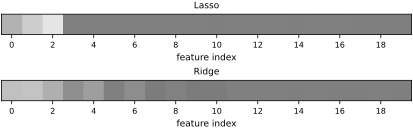

In [7]:
fig, axes = plt.subplots(2, 1, figsize=(7.35, 2.2))
axes[0].imshow(clf.coef_.reshape(1, 20), cmap='gray', vmin=-0.5, vmax=0.5)
axes[0].set(xlabel='feature index', title='Lasso',
            xticks=np.arange(0, 20, 2), xticklabels=np.arange(0, 20, 2),
            yticks=[])
axes[1].imshow(lr.coef_.reshape(1, 20), cmap='gray', vmin=-0.5, vmax=0.5)
axes[1].set(xlabel='feature index', title='Ridge',
            xticks=np.arange(0, 20, 2), xticklabels=np.arange(0, 20, 2),
            yticks=[])
finalize_axes(keep_box=True)

We see that Ridge regression has a lot more non-zero coefficients than Lasso regression.

Let's visualize the predictions as well:

array([<Axes: xlabel='x', ylabel='y'>], dtype=object)

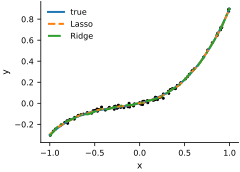

In [8]:
Phi_test = features(xs)
lass_pred = clf.predict(Phi_test)
ridge_pred = lr.predict(Phi_test)

fig, ax = plt.subplots(figsize=FIGURE_SIZES["half_standard"])
ax.plot(x, y, '.', color='k')
ax.plot(xs, f(xs), lw=2, label='true')
ax.plot(xs, lass_pred, '--', lw=2, label='Lasso')
ax.plot(xs, ridge_pred, '-.', lw=2, label='Ridge')
ax.set(xlabel='x', ylabel='y')
ax.legend(loc='best')
finalize_axes(keep_box=False)

## Geometry of the $L^1$ penalty

To understand how Lasso regression works, we need to look at the $L^1$-norm.
Let's work with just two parameters: $\mathbf{w} = (w_1,w_2)$.
The $L^1$-norm is:

$$
\|\mathbf{w}\|_1 = |w_1| + |w_2|.
$$

This is also called the Manhattan norm.
The name reflects the distance traveled along the grid of city blocks.

Let's consider a simple quadratic objective function:

$$
f(\mathbf{w}) = (\mathbf{w}-\mathbf{w}^*)^T\mathbf{A}(\mathbf{w}-\mathbf{w}^*),
$$

where $\mathbf{A}$ is symmetric positive definite, so the minimum is at $\mathbf{w}^*$.
We seek the minimum of the $L^1$-regularized objective function

$$
g(\mathbf{w}) = f(\mathbf{w}) + \lambda\|\mathbf{w}\|_1.
$$

To understand this minimum, first we need to mention that Lasso regression is equivalent to the following constrained optimization problem:

$$
\min_{\mathbf{w}}f(\mathbf{w})\quad\text{subject to}\quad \|\mathbf{w}\|_1\leq t.
$$

To see that this is equivalent to the $L^1$-regularized problem, we can use the Lagrange multiplier method.
For a penalized minimizer $\widehat{\mathbf{w}}_\lambda$, setting $t=\|\widehat{\mathbf{w}}_\lambda\|_1$ gives the same constrained minimizer. Conversely, a Lagrange multiplier supplies a corresponding penalty for a positive constraint radius. This correspondence need not be one-to-one: several penalties can give the zero solution, and sufficiently large radii leave the unpenalized solution unchanged.

Now, we can understand what is going on by looking at the level sets of $f(\mathbf{w})$ and $\|\mathbf{w}\|_1$.

array([<Axes: xlabel='$w_1$', ylabel='$w_2$'>], dtype=object)

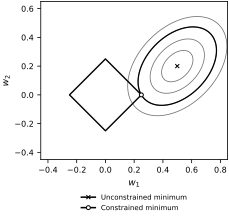

In [9]:
w_star = jnp.array([0.5, 0.2])
A = jnp.array([[1, -0.4], [-0.4, 1]])
t = 0.25
w_constrained = jnp.array([t, 0.0])

from jax import jit

f = jit(vmap(lambda w: (w - w_star) @ A @ (w - w_star)))
minimum = float(f(w_constrained[None, :])[0])
# The corner satisfies the convex optimality condition:
# grad f = (-0.34, -0.20), with |grad f_2| <= -grad f_1.
grad_at_corner = 2 * A @ (w_constrained - w_star)
assert np.allclose(grad_at_corner, [-0.34, -0.20])
assert abs(float(grad_at_corner[1])) <= -float(grad_at_corner[0])

w1 = jnp.linspace(-0.45, 0.85, 500)
w2 = jnp.linspace(-0.45, 0.65, 500)
W1, W2 = jnp.meshgrid(w1, w2)
W_flat = jnp.stack([W1.ravel(), W2.ravel()], axis=1)
F = f(W_flat).reshape(W1.shape)

fig, ax = plt.subplots(figsize=FIGURE_SIZES["half_tall"], constrained_layout=True)
ax.contour(W1, W2, F, levels=[0.01, 0.03, minimum, 0.10],
           colors="0.45", linewidths=0.8)
ax.contour(W1, W2, F, levels=[minimum], colors="black", linewidths=1.25)
ax.plot([t, 0, -t, 0, t], [0, t, 0, -t, 0], color="black", linewidth=1.4)
ax.plot(*w_star, marker="x", color="black", label="Unconstrained minimum")
ax.plot(*w_constrained, marker="o", color="black", markerfacecolor="white",
        markeredgecolor="black", label="Constrained minimum")
ax.set(xlabel="$w_1$", ylabel="$w_2$", aspect="equal")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.18), fontsize=7)
finalize_axes(keep_box=True)


For the plotted radius $t=0.25$, the constrained minimum is $(0.25,0)$, where the quadratic contour touches a corner of the diamond. You are trying to get to the minimum of $f(\mathbf{w})$
while remaining inside the diamond $\|\mathbf{w}\|_1 \leq t$.
The level sets of $\|\mathbf{w}\|_1$ are diamonds.
The constrained minimum of $f(\mathbf{w})$ will be where a level set of $f(\mathbf{w})$ first touches the diamond.
You will often find yourself at a corner of the diamond.
Then one of the components of $\mathbf{w}$ will be zero.

## Bayesian Interpretation of Lasso Regression

Lasso regression can be interpreted as a Bayesian method.
To see this, put a Laplace prior on each one of the weights:

$$
w_j \sim \text{Laplace}(0, b).
$$

The density of the Laplace distribution is:

$$
p(w_j) = \frac{1}{2b}\exp\left(-\frac{|w_j|}{b}\right).
$$

Taking the logarithm of the Laplace prior, we get:

$$
\log p(w_j) = -\frac{|w_j|}{b} + \text{const}.
$$

Therefore, we see that (assuming a Gaussian likelihood), the $L^1$-regularized objective function is (up to an additive constant) equal to the negative log posterior.

Let's visualize the Laplace and Gaussian densities:

array([<Axes: >], dtype=object)

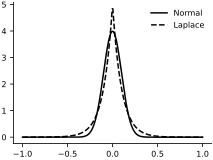

In [10]:
import scipy.stats as st

xs = np.linspace(-1, 1, 300)
fig, ax = plt.subplots(figsize=FIGURE_SIZES["half_standard"])
ax.plot(xs, st.norm.pdf(xs, 0, 0.1), color='black', linestyle='-',
        label='Normal')
ax.plot(xs, st.laplace.pdf(xs, 0, 0.1), color='black', linestyle='--',
        label='Laplace')
ax.legend()
finalize_axes(keep_box=False)